# Notebook 02 — Empty-Lattice Band Structure

Numerical band structure of the 2D square NFE model with $V_0 = 0$ along the conventional path $\Gamma \to X \to M \to \Gamma$. With no potential the eigenvalues are simply the free-electron energies $|\mathbf{k} + \mathbf{G}|^2$ in the reduced-zone scheme; the diagonalization output must reproduce them exactly. The dashed black overlay is the analytic answer computed directly from $\{|\mathbf{k} + \mathbf{G}|^2\}$ for all G in the basis — agreement validates `build_H`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.lattice import high_symmetry_path
from src.hamiltonian import cosine_potential
from src.bands import (
    compute_bands_along_path,
    free_electron_energies_along_path,
)

FIG_DIR = ROOT / "figures" / "02_empty_lattice"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_CUT = 3
N_PER_SEG = 120
N_BANDS_PLOT = 8
PATH_NODES = high_symmetry_path()
NODE_LABELS = [r"$\Gamma$", "X", "M", r"$\Gamma$"]

In [2]:
V_func = cosine_potential(V_0=0.0)
k_dist, E_num, node_dists = compute_bands_along_path(PATH_NODES, N_PER_SEG, V_func, N_CUT)
_, E_ana, _ = free_electron_energies_along_path(PATH_NODES, N_PER_SEG, N_CUT)

max_residual = np.max(np.abs(E_num[:, :N_BANDS_PLOT] - E_ana[:, :N_BANDS_PLOT]))
print(f"k-points along path: {k_dist.size}")
print(f"Plane waves in basis: {E_num.shape[1]}")
print(f"Max |E_numerical - E_analytic| over lowest {N_BANDS_PLOT} bands: {max_residual:.3e}")

k-points along path: 358
Plane waves in basis: 49
Max |E_numerical - E_analytic| over lowest 8 bands: 0.000e+00


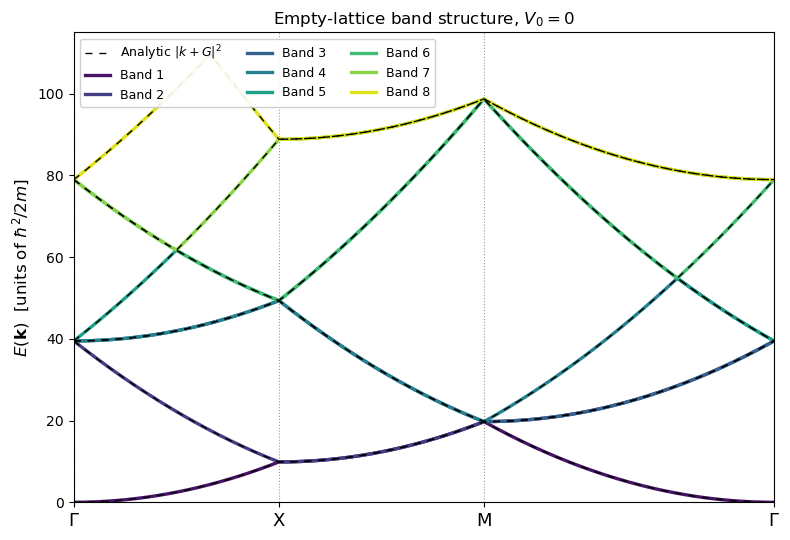

In [3]:
fig, ax = plt.subplots(figsize=(8.0, 5.5))

# Numerical bands as solid colored lines (drawn first).
colors = plt.cm.viridis(np.linspace(0.05, 0.95, N_BANDS_PLOT))
for n in range(N_BANDS_PLOT):
    ax.plot(k_dist, E_num[:, n], color=colors[n], linewidth=2.4, zorder=2,
            label=f"Band {n + 1}")

# Analytic free-electron parabolas as thin dashed black lines on top, so the
# dashes are visible as gaps in the colored bands — confirming overlap.
for n in range(N_BANDS_PLOT):
    ax.plot(k_dist, E_ana[:, n], color="black", linestyle=(0, (5, 5)),
            linewidth=1.0, zorder=3,
            label=r"Analytic $|k+G|^2$" if n == 0 else None)

# Vertical dashed guides at high-symmetry points.
for x in node_dists:
    ax.axvline(x, color="0.6", linestyle=":", linewidth=0.8, zorder=0)

ax.set_xticks(node_dists)
ax.set_xticklabels(NODE_LABELS, fontsize=13)
ax.set_xlim(k_dist[0], k_dist[-1])
ax.set_ylim(0, np.max(E_num[:, N_BANDS_PLOT - 1]) * 1.05)
ax.set_ylabel(r"$E(\mathbf{k})$  [units of $\hbar^2/2m$]", fontsize=12)
ax.set_title("Empty-lattice band structure, $V_0 = 0$")

handles, labels = ax.get_legend_handles_labels()
order = [labels.index(r"Analytic $|k+G|^2$")] + [
    i for i, l in enumerate(labels) if l != r"Analytic $|k+G|^2$"
]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          loc="upper left", ncol=3, fontsize=9, framealpha=0.92)

fig.tight_layout()
fig.savefig(FIG_DIR / "figure_02_empty_lattice_bands.png", dpi=180, bbox_inches="tight")
plt.show()